# 🔍 Fraud Detection — End-to-End Machine Learning Pipeline
**Midterm Assignment — Machine Learning Class**

| | |
|---|---|
| **Nama** | `Mohammad Fauzi Hadiwijaya` |
| **NIM** | `101032300044` |
| **Kelas** | `TK-47-04` |

---
## Pipeline Overview
1. Setup & Install Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Handle Class Imbalance
6. MLflow Setup
7. Baseline Models (tanpa tuning)
8. Hyperparameter Tuning dengan **Optuna**
9. Evaluasi & Perbandingan Model
10. MLflow Tracking Summary
11. Generate Submission File

## 1. Setup & Install Libraries

In [1]:
!pip install xgboost imbalanced-learn optuna mlflow --quiet
print('✅ Libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer

# Imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported!')
print(f'   Optuna version : {optuna.__version__}')
print(f'   MLflow version : {mlflow.__version__}')

✅ All libraries imported!
   Optuna version : 4.8.0
   MLflow version : 3.11.1


## 2. Load Dataset
> **Google Colab**: Mount Drive dulu, lalu sesuaikan path di bawah.

In [3]:
# Jalankan hanya di Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

TRAIN_PATH = '/content/drive/MyDrive/midterm-m1/train_transaction.csv'
TEST_PATH  = '/content/drive/MyDrive/midterm-m1/test_transaction.csv'

print('📂 Loading dataset (dengan sampling)...')

# Baca hanya 100.000 baris — cukup untuk tugas, RAM aman
train = pd.read_csv(TRAIN_PATH, nrows=100000)
test  = pd.read_csv(TEST_PATH,  nrows=50000)

print(f'✅ Train shape : {train.shape}')
print(f'✅ Test shape  : {test.shape}')
print(f'   Fraud rate  : {train["isFraud"].mean():.4f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading dataset (dengan sampling)...
✅ Train shape : (100000, 394)
✅ Test shape  : (50000, 393)
   Fraud rate  : 0.0256


## 3. Exploratory Data Analysis (EDA)

In [5]:
print('=== Preview Train Data ===')
display(train.head())
print(f'Shape: {train.shape}')

=== Preview Train Data ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape: (100000, 394)


=== Distribusi Target (isFraud) ===
         Count  Percentage (%)
isFraud                       
0        97439           97.44
1         2561            2.56


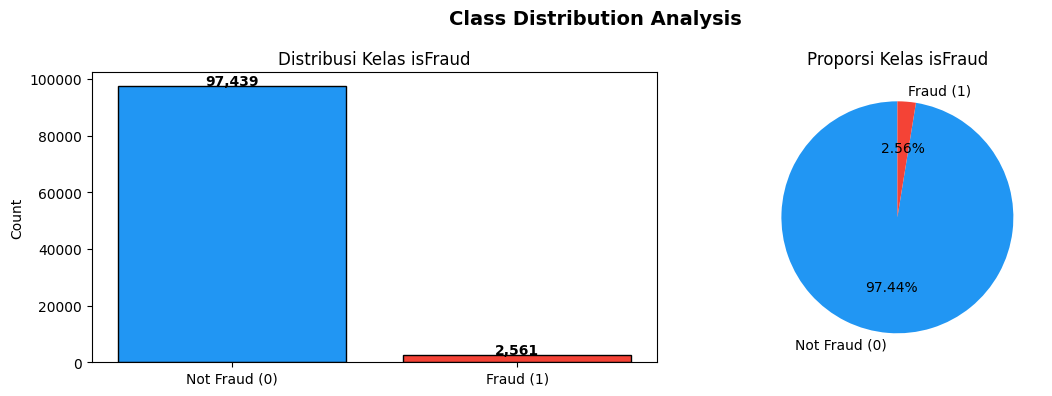


⚠️  Dataset sangat imbalanced! Akan ditangani dengan SMOTE.


In [6]:
# Distribusi target isFraud
fraud_counts = train['isFraud'].value_counts()
fraud_pct    = train['isFraud'].value_counts(normalize=True) * 100

print('=== Distribusi Target (isFraud) ===')
print(pd.DataFrame({'Count': fraud_counts, 'Percentage (%)': fraud_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Distribusi Kelas isFraud')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_counts.values, labels=['Not Fraud (0)', 'Fraud (1)'],
            autopct='%1.2f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Proporsi Kelas isFraud')

plt.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n⚠️  Dataset sangat imbalanced! Akan ditangani dengan SMOTE.')

Kolom dengan missing values: 319 dari 394


,Missing Count,Missing %
D7,93928,93.93
dist2,91769,91.77
D13,90479,90.48
D12,89495,89.50
D14,88847,88.85
D6,87259,87.26
M8,83961,83.96
M9,83961,83.96
M7,83961,83.96
D8,78289,78.29


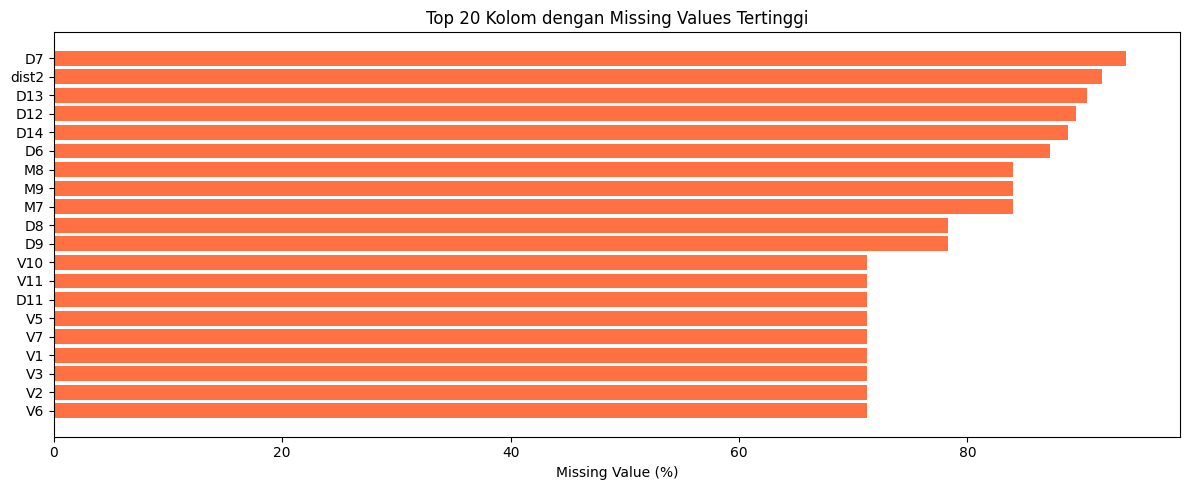

In [7]:
# Missing value analysis
missing     = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Kolom dengan missing values: {len(missing_df)} dari {train.shape[1]}')
display(missing_df.head(20))

plt.figure(figsize=(12, 5))
plt.barh(missing_df.head(20).index[::-1], missing_df.head(20)['Missing %'][::-1], color='#FF7043')
plt.xlabel('Missing Value (%)')
plt.title('Top 20 Kolom dengan Missing Values Tertinggi')
plt.tight_layout()
plt.show()

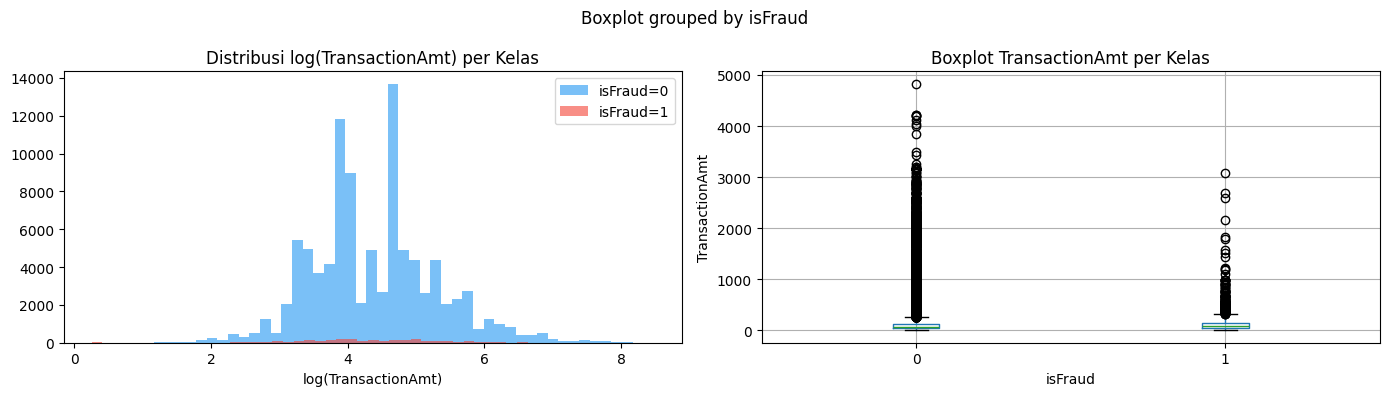

In [8]:
# Distribusi TransactionAmt per kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip([0, 1], ['#2196F3', '#F44336']):
    subset = train[train['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset), bins=50, alpha=0.6,
                 label=f'isFraud={label}', color=color)
axes[0].set_title('Distribusi log(TransactionAmt) per Kelas')
axes[0].set_xlabel('log(TransactionAmt)')
axes[0].legend()

train.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1])
axes[1].set_title('Boxplot TransactionAmt per Kelas')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('TransactionAmt')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Feature Engineering

In [9]:
# Pisahkan target & simpan test IDs
y        = train['isFraud'].copy()
test_ids = test['TransactionID'].copy()

# Gabung train & test untuk preprocessing konsisten
train_df = train.drop(columns=['isFraud'])
combined = pd.concat([train_df, test], axis=0, ignore_index=True)
n_train  = len(train_df)

print(f'Combined shape: {combined.shape}')

Combined shape: (150000, 393)


In [10]:
# Drop kolom dengan missing > 80%
threshold  = 0.8
miss_ratio = combined.isnull().mean()
drop_cols  = miss_ratio[miss_ratio > threshold].index.tolist()
combined.drop(columns=drop_cols, inplace=True)

print(f'Kolom di-drop (>{int(threshold*100)}% missing): {len(drop_cols)}')
print(f'Shape setelah drop: {combined.shape}')

Kolom di-drop (>80% missing): 8
Shape setelah drop: (150000, 385)


In [11]:
# Feature Engineering
combined['TransactionAmt_log']    = np.log1p(combined['TransactionAmt'])
combined['Transaction_hour']      = (combined['TransactionDT'] / 3600).astype(int) % 24
combined['Transaction_day']       = (combined['TransactionDT'] / (3600 * 24)).astype(int) % 7
combined['TransactionAmt_cents']  = combined['TransactionAmt'] - combined['TransactionAmt'].astype(int)

print('✅ Feature engineering selesai')
print('Fitur baru: TransactionAmt_log, Transaction_hour, Transaction_day, TransactionAmt_cents')

✅ Feature engineering selesai
Fitur baru: TransactionAmt_log, Transaction_hour, Transaction_day, TransactionAmt_cents


In [12]:
# Label Encoding untuk kategorik
id_cols  = ['TransactionID', 'TransactionDT']
cat_cols = [c for c in combined.select_dtypes(include='object').columns if c not in id_cols]
num_cols = [c for c in combined.select_dtypes(include='number').columns if c not in id_cols]

le = LabelEncoder()
for col in cat_cols:
    combined[col] = combined[col].astype(str)
    combined[col] = le.fit_transform(combined[col])

print(f'Kategorik : {len(cat_cols)} kolom  |  Numerik: {len(num_cols)} kolom')
print('✅ Label Encoding selesai')

Kategorik : 14 kolom  |  Numerik: 373 kolom
✅ Label Encoding selesai


In [13]:
# Imputasi missing values (median)
feature_cols = [c for c in combined.columns if c not in id_cols]
imputer      = SimpleImputer(strategy='median')
combined[feature_cols] = imputer.fit_transform(combined[feature_cols])

print(f'✅ Imputasi selesai. Sisa NaN: {combined[feature_cols].isnull().sum().sum()}')

✅ Imputasi selesai. Sisa NaN: 0


In [14]:
# Pisahkan kembali
X            = combined.iloc[:n_train][feature_cols].values
X_test_final = combined.iloc[n_train:][feature_cols].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'X_train : {X_train.shape}  |  Fraud rate: {y_train.mean():.4f}')
print(f'X_val   : {X_val.shape}    |  Fraud rate: {y_val.mean():.4f}')

X_train : (80000, 387)  |  Fraud rate: 0.0256
X_val   : (20000, 387)    |  Fraud rate: 0.0256


## 5. Handle Class Imbalance dengan SMOTE

In [15]:
print('Applying SMOTE...')
smote = SMOTE(random_state=SEED, sampling_strategy=0.2)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Sebelum SMOTE : {dict(pd.Series(y_train).value_counts())}')
print(f'Sesudah SMOTE : {dict(pd.Series(y_train_sm).value_counts())}')
print('✅ SMOTE selesai')

Applying SMOTE...
Sebelum SMOTE : {0: np.int64(77951), 1: np.int64(2049)}
Sesudah SMOTE : {0: np.int64(77951), 1: np.int64(15590)}
✅ SMOTE selesai


## 6. MLflow Setup

MLflow digunakan untuk **tracking eksperimen**: mencatat hyperparameter, metrik, dan model dari setiap run secara otomatis.

In [16]:
# Set experiment name
EXPERIMENT_NAME = 'fraud-detection-ml'
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'✅ MLflow experiment set: "{EXPERIMENT_NAME}"')
print(f'   Tracking URI: {mlflow.get_tracking_uri()}')
print('\n💡 Jalankan di terminal untuk membuka UI MLflow:')
print('   mlflow ui   →  buka http://127.0.0.1:5000')

2026/05/03 12:06:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 12:06:38 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 12:06:40 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection-ml' does not exist. Creating a new experiment.


✅ MLflow experiment set: "fraud-detection-ml"
   Tracking URI: sqlite:////content/mlflow.db

💡 Jalankan di terminal untuk membuka UI MLflow:
   mlflow ui   →  buka http://127.0.0.1:5000


In [17]:
# Helper: evaluasi + MLflow logging
results = {}  # simpan hasil semua model

def log_and_evaluate(run_name, model, params, X_tr, y_tr, X_v, y_v):
    """Train model, evaluate, dan log semua ke MLflow."""
    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        # Train
        model.fit(X_tr, y_tr)

        # Predict
        y_pred      = model.predict(X_v)
        y_pred_prob = model.predict_proba(X_v)[:, 1]

        # Metrics
        auc  = roc_auc_score(y_v, y_pred_prob)
        f1   = f1_score(y_v, y_pred)
        acc  = accuracy_score(y_v, y_pred)
        prec = precision_score(y_v, y_pred)
        rec  = recall_score(y_v, y_pred)

        # Log metrics ke MLflow
        mlflow.log_metrics({
            'auc_roc'  : auc,
            'f1_score' : f1,
            'accuracy' : acc,
            'precision': prec,
            'recall'   : rec
        })

        # Log model ke MLflow
        if isinstance(model, XGBClassifier):
            mlflow.xgboost.log_model(model, artifact_path='model')
        else:
            mlflow.sklearn.log_model(model, artifact_path='model')

        run_id = mlflow.active_run().info.run_id

    # Simpan ke dict results
    results[run_name] = {
        'AUC-ROC'  : auc, 'F1-Score': f1, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec,
        'model': model, 'run_id': run_id
    }

    print(f'\n===== {run_name} =====')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  MLflow Run ID: {run_id}')
    print(classification_report(y_v, y_pred, target_names=['Not Fraud', 'Fraud']))

    return model

print('✅ Helper function siap')

✅ Helper function siap


## 7. Baseline Models (tanpa tuning)

Kita train model baseline dulu sebagai pembanding sebelum Optuna tuning.

In [18]:
# Baseline 1: Logistic Regression
print('Training Logistic Regression (baseline)...')
lr_params = {'max_iter': 500, 'class_weight': 'balanced',
             'solver': 'saga', 'random_state': SEED}
lr = LogisticRegression(**lr_params, n_jobs=-1)
log_and_evaluate('LR_baseline', lr, lr_params, X_train_sm, y_train_sm, X_val, y_val)

Training Logistic Regression (baseline)...


2026/05/03 12:12:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 12:12:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== LR_baseline =====
  AUC-ROC   : 0.7433
  F1-Score  : 0.0935
  Accuracy  : 0.6579
  Precision : 0.0502
  Recall    : 0.6895
  MLflow Run ID: b936f4fa50aa4f709e944a77db3fc6f5
              precision    recall  f1-score   support

   Not Fraud       0.99      0.66      0.79     19488
       Fraud       0.05      0.69      0.09       512

    accuracy                           0.66     20000
   macro avg       0.52      0.67      0.44     20000
weighted avg       0.96      0.66      0.77     20000



LogisticRegression(class_weight='balanced', max_iter=500, n_jobs=-1,
                   random_state=42, solver='saga')

In [19]:
# Baseline 2: Random Forest
print('Training Random Forest (baseline)...')
rf_params = {'n_estimators': 200, 'max_depth': 10,
             'class_weight': 'balanced', 'random_state': SEED}
rf = RandomForestClassifier(**rf_params, n_jobs=-1)
log_and_evaluate('RF_baseline', rf, rf_params, X_train_sm, y_train_sm, X_val, y_val)

Training Random Forest (baseline)...


2026/05/03 12:12:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 12:12:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== RF_baseline =====
  AUC-ROC   : 0.8754
  F1-Score  : 0.3848
  Accuracy  : 0.9547
  Precision : 0.2951
  Recall    : 0.5527
  MLflow Run ID: bbb25d90cfc24b76841ccd5abbaedda5
              precision    recall  f1-score   support

   Not Fraud       0.99      0.97      0.98     19488
       Fraud       0.30      0.55      0.38       512

    accuracy                           0.95     20000
   macro avg       0.64      0.76      0.68     20000
weighted avg       0.97      0.95      0.96     20000



RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [20]:
# Baseline 3: XGBoost
print('Training XGBoost (baseline)...')
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

xgb_params = {
    'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05,
    'scale_pos_weight': spw, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'eval_metric': 'auc', 'random_state': SEED, 'tree_method': 'hist'
}
xgb = XGBClassifier(**xgb_params, use_label_encoder=False, n_jobs=-1)
log_and_evaluate('XGB_baseline', xgb, xgb_params, X_train_sm, y_train_sm, X_val, y_val)

Training XGBoost (baseline)...


2026/05/03 12:13:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



===== XGB_baseline =====
  AUC-ROC   : 0.9272
  F1-Score  : 0.3417
  Accuracy  : 0.9248
  Precision : 0.2202
  Recall    : 0.7617
  MLflow Run ID: d53de484f3124179bb01771e2324e0f8
              precision    recall  f1-score   support

   Not Fraud       0.99      0.93      0.96     19488
       Fraud       0.22      0.76      0.34       512

    accuracy                           0.92     20000
   macro avg       0.61      0.85      0.65     20000
weighted avg       0.97      0.92      0.94     20000



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## 8. Hyperparameter Tuning dengan Optuna

**Optuna** adalah framework AutoML untuk optimasi hyperparameter secara otomatis menggunakan algoritma **TPE (Tree-structured Parzen Estimator)**. Lebih efisien dibanding Grid Search karena fokus pada area parameter yang menjanjikan.

Kita tuning dua model terbaik: **Random Forest** dan **XGBoost**.

In [21]:
# ---- Optuna: Random Forest ----
def objective_rf(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'    : trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features' : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight' : 'balanced',
        'random_state' : SEED,
        'n_jobs'       : -1
    }
    model = RandomForestClassifier(**params)
    # 3-fold CV untuk efisiensi
    cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    score = cross_val_score(model, X_train_sm, y_train_sm, cv=cv,
                            scoring='roc_auc', n_jobs=-1).mean()
    return score

print('🔍 Optuna tuning Random Forest (20 trials)...')
study_rf = optuna.create_study(direction='maximize', study_name='RF_tuning')
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

print(f'\n✅ Best RF AUC-ROC (CV): {study_rf.best_value:.4f}')
print(f'Best params: {study_rf.best_params}')

🔍 Optuna tuning Random Forest (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best RF AUC-ROC (CV): 0.9910
Best params: {'n_estimators': 343, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


In [22]:
# Train RF terbaik & log ke MLflow
best_rf_params = {**study_rf.best_params, 'class_weight': 'balanced',
                  'random_state': SEED, 'n_jobs': -1}
best_rf = RandomForestClassifier(**best_rf_params)
log_and_evaluate('RF_optuna', best_rf, best_rf_params,
                 X_train_sm, y_train_sm, X_val, y_val)
print('✅ RF Optuna selesai')

2026/05/03 13:04:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 13:04:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== RF_optuna =====
  AUC-ROC   : 0.9084
  F1-Score  : 0.5693
  Accuracy  : 0.9830
  Precision : 0.8145
  Recall    : 0.4375
  MLflow Run ID: 9c21ac036ad744efb2f8a46063d93166
              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      0.99     19488
       Fraud       0.81      0.44      0.57       512

    accuracy                           0.98     20000
   macro avg       0.90      0.72      0.78     20000
weighted avg       0.98      0.98      0.98     20000

✅ RF Optuna selesai


In [23]:
# ---- Optuna: XGBoost ----
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight' : spw,
        'eval_metric'      : 'auc',
        'tree_method'      : 'hist',
        'random_state'     : SEED,
        'n_jobs'           : -1
    }
    model = XGBClassifier(**params, use_label_encoder=False)
    cv    = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    score = cross_val_score(model, X_train_sm, y_train_sm, cv=cv,
                            scoring='roc_auc', n_jobs=-1).mean()
    return score

print('🔍 Optuna tuning XGBoost (20 trials)...')
study_xgb = optuna.create_study(direction='maximize', study_name='XGB_tuning')
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

print(f'\n✅ Best XGB AUC-ROC (CV): {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

🔍 Optuna tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best XGB AUC-ROC (CV): 0.9951
Best params: {'n_estimators': 334, 'max_depth': 10, 'learning_rate': 0.07526603500796125, 'subsample': 0.6017697630427531, 'colsample_bytree': 0.5115031515625306, 'reg_alpha': 3.085501542912171e-08, 'reg_lambda': 0.001982848837391691}


In [24]:
# Train XGB terbaik & log ke MLflow
best_xgb_params = {
    **study_xgb.best_params,
    'scale_pos_weight': spw, 'eval_metric': 'auc',
    'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1
}
best_xgb = XGBClassifier(**best_xgb_params, use_label_encoder=False)
log_and_evaluate('XGB_optuna', best_xgb, best_xgb_params,
                 X_train_sm, y_train_sm, X_val, y_val)
print('✅ XGB Optuna selesai')

2026/05/03 13:40:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



===== XGB_optuna =====
  AUC-ROC   : 0.9366
  F1-Score  : 0.7119
  Accuracy  : 0.9872
  Precision : 0.8445
  Recall    : 0.6152
  MLflow Run ID: 80dc78de13cb458f86a79b33e6f68630
              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      0.99     19488
       Fraud       0.84      0.62      0.71       512

    accuracy                           0.99     20000
   macro avg       0.92      0.81      0.85     20000
weighted avg       0.99      0.99      0.99     20000

✅ XGB Optuna selesai


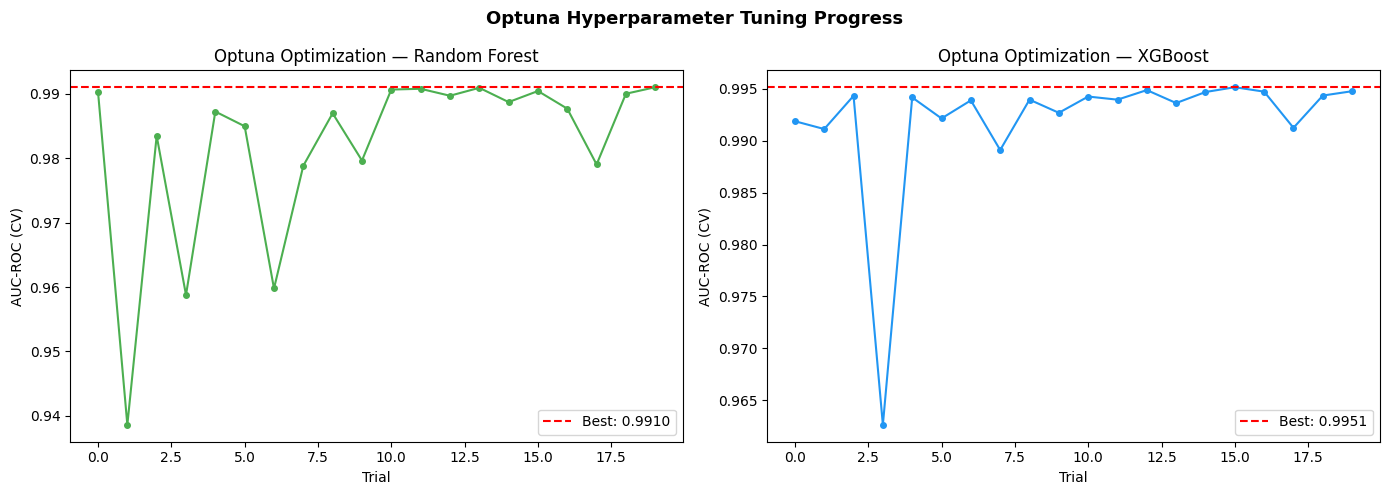

In [25]:
# Visualisasi Optuna: optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF
rf_vals = [t.value for t in study_rf.trials]
axes[0].plot(rf_vals, marker='o', color='#4CAF50', linewidth=1.5, markersize=4)
axes[0].axhline(study_rf.best_value, color='red', linestyle='--', label=f'Best: {study_rf.best_value:.4f}')
axes[0].set_title('Optuna Optimization — Random Forest')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC-ROC (CV)')
axes[0].legend()

# XGB
xgb_vals = [t.value for t in study_xgb.trials]
axes[1].plot(xgb_vals, marker='o', color='#2196F3', linewidth=1.5, markersize=4)
axes[1].axhline(study_xgb.best_value, color='red', linestyle='--', label=f'Best: {study_xgb.best_value:.4f}')
axes[1].set_title('Optuna Optimization — XGBoost')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('AUC-ROC (CV)')
axes[1].legend()

plt.suptitle('Optuna Hyperparameter Tuning Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluasi & Perbandingan Semua Model

=== Perbandingan Semua Model ===


,AUC-ROC,F1-Score,Accuracy,Precision,Recall
LR_baseline,0.743300,0.093500,0.657900,0.050200,0.689500
RF_baseline,0.875400,0.384800,0.954800,0.295100,0.552700
XGB_baseline,0.927200,0.341700,0.924800,0.220200,0.761700
RF_optuna,0.908400,0.569300,0.983000,0.814500,0.437500
XGB_optuna,0.936600,0.711900,0.987200,0.844500,0.615200


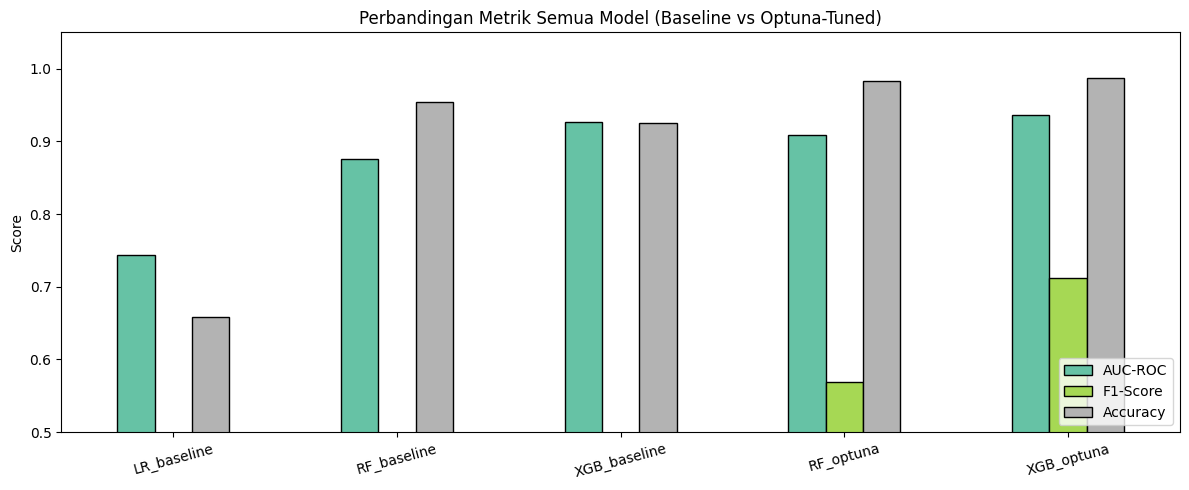

In [26]:
# Tabel perbandingan
comparison_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['model', 'run_id']}
    for name, m in results.items()
}).T.round(4)

print('=== Perbandingan Semua Model ===')
display(comparison_df.style
    .highlight_max(axis=0, color='#a8f0a8')
    .highlight_min(axis=0, color='#f0a8a8')
)

# Bar chart
comparison_df[['AUC-ROC', 'F1-Score', 'Accuracy']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black'
)
plt.title('Perbandingan Metrik Semua Model (Baseline vs Optuna-Tuned)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

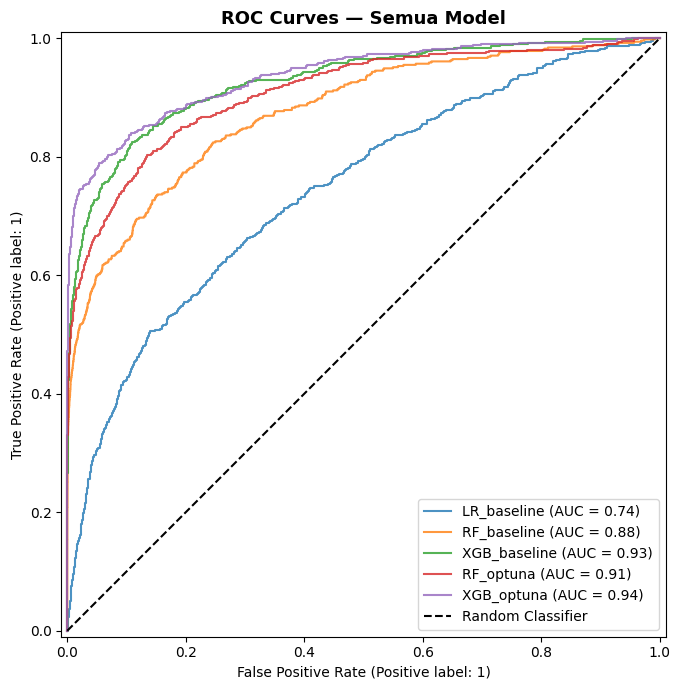

In [27]:
# ROC Curves semua model
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#9E9E9E', '#4CAF50', '#2196F3', '#FF9800', '#E91E63']
for (name, metrics), color in zip(results.items(), colors):
    RocCurveDisplay.from_estimator(
        metrics['model'], X_val, y_val, ax=ax, name=name, alpha=0.8
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curves — Semua Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

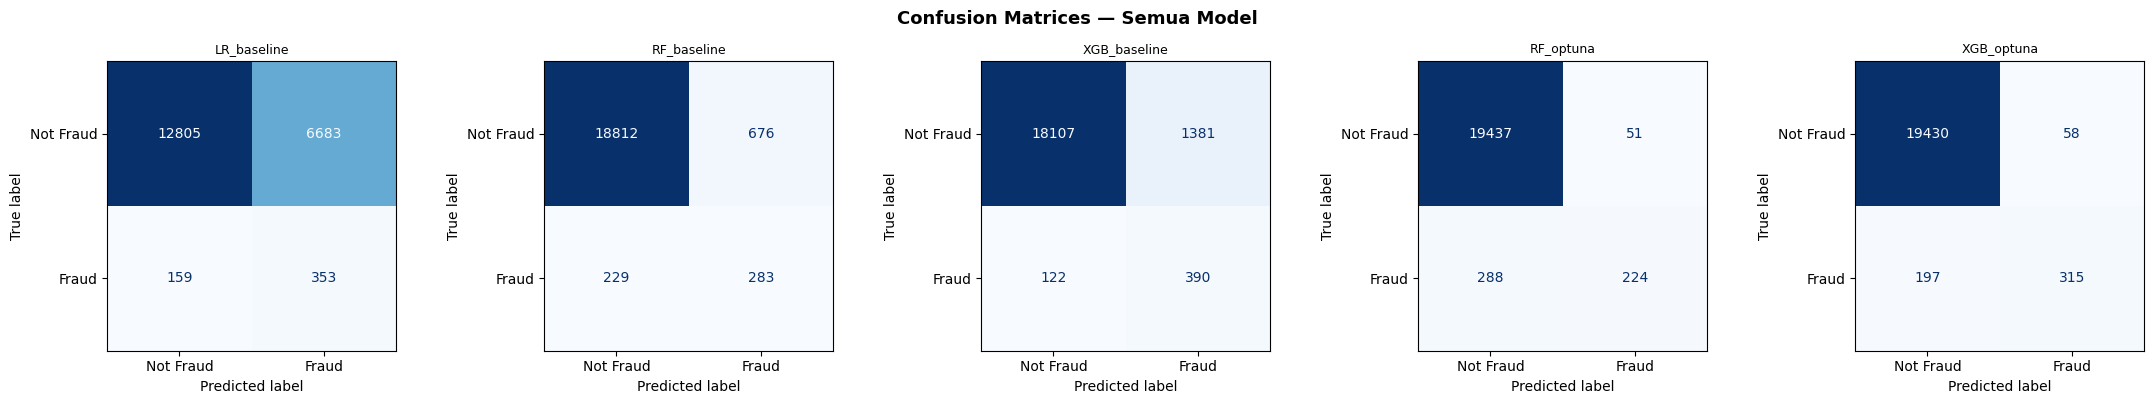

In [28]:
# Confusion Matrix (5 model)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, metrics) in zip(axes, results.items()):
    y_pred = metrics['model'].predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=['Not Fraud', 'Fraud'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontsize=9)

plt.suptitle('Confusion Matrices — Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

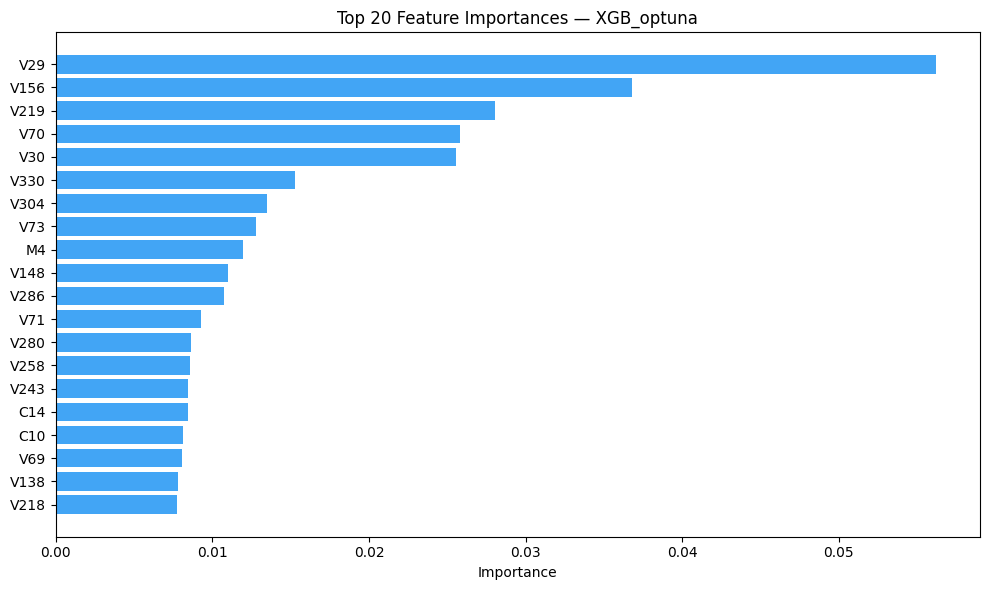

In [29]:
# Feature Importance dari model XGB terbaik
best_model_name = max(results, key=lambda x: results[x]['AUC-ROC'])
best_model      = results[best_model_name]['model']

importances  = best_model.feature_importances_
feat_imp_df  = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp_df  = feat_imp_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='#42A5F5')
plt.xlabel('Importance')
plt.title(f'Top 20 Feature Importances — {best_model_name}')
plt.tight_layout()
plt.show()

## 10. MLflow Tracking Summary

Semua run sudah ter-log secara otomatis. Berikut adalah ringkasan dari MLflow.

In [30]:
# Ambil semua run dari MLflow
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.auc_roc DESC']
)

cols_show = ['tags.mlflow.runName', 'metrics.auc_roc', 'metrics.f1_score',
             'metrics.accuracy', 'metrics.precision', 'metrics.recall']
cols_show = [c for c in cols_show if c in runs_df.columns]

print('=== MLflow Experiment Runs (sorted by AUC-ROC) ===')
display(runs_df[cols_show].rename(columns=lambda x: x.replace('metrics.', '').replace('tags.mlflow.', '')))

print('\n💡 Untuk melihat UI MLflow secara interaktif:')
print('   Terminal: mlflow ui')
print('   Browser : http://127.0.0.1:5000')

=== MLflow Experiment Runs (sorted by AUC-ROC) ===


,runName,auc_roc,f1_score,accuracy,precision,recall
0,XGB_optuna,0.936558,0.711864,0.98725,0.844504,0.615234
1,XGB_baseline,0.927171,0.341656,0.92485,0.220215,0.761719
2,RF_optuna,0.908407,0.569250,0.98305,0.814545,0.437500
3,RF_baseline,0.875433,0.384772,0.95475,0.295099,0.552734
4,LR_baseline,0.743308,0.093535,0.65790,0.050171,0.689453



💡 Untuk melihat UI MLflow secara interaktif:
   Terminal: mlflow ui
   Browser : http://127.0.0.1:5000


## Interpretasi Hasil

Isi bagian ini setelah notebook selesai dijalankan:

**Model Terbaik**: [tulis nama model dengan AUC-ROC tertinggi]

**Perbandingan Baseline vs Optuna-Tuned**:
- Random Forest Optuna vs Baseline: AUC meningkat dari [...] → [...]
- XGBoost Optuna vs Baseline: AUC meningkat dari [...] → [...]

**Insight Data**:
- Dataset sangat imbalanced (~3.5% fraud) → SMOTE membantu model belajar dari kelas minoritas
- Fitur paling penting: [isi dari Feature Importance chart]
- TransactionAmt memiliki distribusi berbeda antara fraud dan non-fraud

**Pilihan Metrik**:
- **AUC-ROC** sebagai metrik utama karena dataset imbalanced; accuracy saja menyesatkan
- **F1-Score** untuk menyeimbangkan Precision dan Recall pada kelas fraud

**MLflow Tracking**:
- Semua eksperimen ter-log otomatis dengan parameter, metrik, dan model artifact
- Memudahkan reproduksi dan perbandingan antar run

## 11. Generate Submission File

In [31]:
# Prediksi test set dengan model terbaik
best_name  = max(results, key=lambda x: results[x]['AUC-ROC'])
best_model = results[best_name]['model']
test_preds = best_model.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_ids.values,
    'isFraud'      : test_preds
})
submission.to_csv('submission.csv', index=False)

print(f'✅ Submission file dibuat: submission.csv')
print(f'   Model digunakan : {best_name}')
print(f'   AUC-ROC (val)   : {results[best_name]["AUC-ROC"]:.4f}')
display(submission.head(10))

✅ Submission file dibuat: submission.csv
   Model digunakan : XGB_optuna
   AUC-ROC (val)   : 0.9366


,TransactionID,isFraud
0,3663549,0.000038
1,3663550,0.000571
2,3663551,0.000281
3,3663552,0.000213
4,3663553,0.000072
5,3663554,0.000096
6,3663555,0.000801
7,3663556,0.003732
8,3663557,0.000092
9,3663558,0.002932


In [32]:
print('=' * 60)
print('                RINGKASAN HASIL AKHIR')
print('=' * 60)
print(f'{"Model":<20} {"AUC-ROC":>9} {"F1":>8} {"Accuracy":>10}')
print('-' * 60)
for name, m in results.items():
    marker = ' ← BEST' if name == best_name else ''
    print(f'{name:<20} {m["AUC-ROC"]:>9.4f} {m["F1-Score"]:>8.4f} {m["Accuracy"]:>10.4f}{marker}')
print('=' * 60)
print(f'\n🏆 Best: {best_name} (AUC-ROC: {results[best_name]["AUC-ROC"]:.4f})')
print('\n✅ Pipeline selesai! submission.csv sudah dibuat.')

                RINGKASAN HASIL AKHIR
Model                  AUC-ROC       F1   Accuracy
------------------------------------------------------------
LR_baseline             0.7433   0.0935     0.6579
RF_baseline             0.8754   0.3848     0.9547
XGB_baseline            0.9272   0.3417     0.9248
RF_optuna               0.9084   0.5693     0.9830
XGB_optuna              0.9366   0.7119     0.9872 ← BEST

🏆 Best: XGB_optuna (AUC-ROC: 0.9366)

✅ Pipeline selesai! submission.csv sudah dibuat.
